In [1]:
EXP_NAME="30APR"
raw_dataset="30APR/unbiased_raw"
n_test = 1000
n_train = 800
seed = 4

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm, gamma, beta, truncnorm
from scipy.special import expit
from scipy.optimize import bisect
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import simulate_selection_bias, proportion_preserving_sampling, class_balanced_sampling, scale_dataset, apply_additive_unfair_bias, plot_cont_feature, plot_cat_feature

In [4]:
raw_dataset = pd.read_csv(f'../../data/synth/{raw_dataset}.csv')

___

# Introducing bias

## Additive bias

In [5]:
add_df = apply_additive_unfair_bias(raw_dataset, s_target=0, bias_prob=0.5, s1_max_shift=2, b1_mean_shift=12.0, b1_std_shift=3.0, proc_risk_penalty=4, seed=seed)

# Sampling

## Proportion-preserving sampling

In [6]:
add_train, add_test = proportion_preserving_sampling(add_df, n_train, n_test, seed)
print(f"Target Train size: {n_train} | Actual size: {len(add_train)}")
print(f"Prevalence in Train sample: {add_train['outcome_Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(add_test)}")
print(f"Prevalence in Test sample: {add_test['outcome_Y'].mean():.2%}")

Target Train size: 800 | Actual size: 819
Prevalence in Train sample: 11.11%
Target Test size: 1000 | Actual size: 1020
Prevalence in Test sample: 10.88%


## Class-balanced sampling

In [7]:
add_classbal_train, add_classbal_test = class_balanced_sampling(add_df, n_train, n_test, seed)
print(f"Target Train size: {n_train} | Actual size: {len(add_classbal_train)}")
print(f"Prevalence in Train sample: {add_classbal_train['outcome_Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(add_classbal_test)}")
print(f"Prevalence in Test sample: {add_classbal_test['outcome_Y'].mean():.2%}")

Target Train size: 800 | Actual size: 792
Prevalence in Train sample: 49.49%
Target Test size: 1000 | Actual size: 986
Prevalence in Test sample: 49.39%


## Selection bias

Target Train size: 800 | Actual size: 800
Prevalence in Train sample: 50.00%
Target Test size: 1000 | Actual size: 1000
Prevalence in Test sample: 50.00%


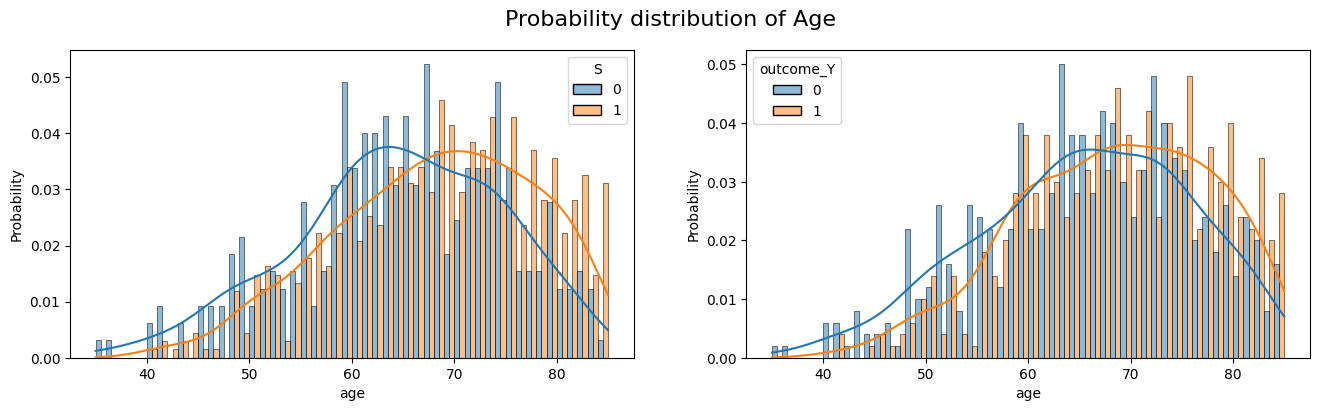

In [8]:
# Run the selection
add_selbias_train, add_selbias_test = simulate_selection_bias(add_df, n_train, n_test, seed)
print(f"Target Train size: {n_train} | Actual size: {len(add_selbias_train)}")
print(f"Prevalence in Train sample: {add_selbias_train['outcome_Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(add_selbias_test)}")
print(f"Prevalence in Test sample: {add_selbias_test['outcome_Y'].mean():.2%}")
fig = plot_cont_feature(add_selbias_test, 'age', 'Age')

# Data processing

In [9]:
norm_variables = ['age', "biomarker_1_obs", "biomarker_3"]
skewed_variables = ["biomarker_2"]

import os
data_dir = f"{PROJECT_ROOT}/data/synth/{EXP_NAME}"
os.makedirs(data_dir, exist_ok=True)

# Additive bias + Preserved Proportion sampling dataset
add_train_proc = scale_dataset(add_train, norm_variables, skewed_variables)
add_test_proc = scale_dataset(add_test, norm_variables, skewed_variables)

add_train_proc.to_csv(f'{data_dir}/add_train.csv', index=False)
add_test_proc.to_csv(f'{data_dir}/add_test.csv', index=False)

# Additive bias + Class-balancing sampling dataset
add_classbal_train_proc = scale_dataset(add_classbal_train, norm_variables, skewed_variables)
add_classbal_test_proc = scale_dataset(add_classbal_test, norm_variables, skewed_variables)

add_classbal_train_proc.to_csv(f'{data_dir}/add_classbal_train.csv', index=False)
add_classbal_test_proc.to_csv(f'{data_dir}/add_classbal_test.csv', index=False)

# Additive bias + Selection bias dataset
add_selbias_train_proc = scale_dataset(add_selbias_train, norm_variables, skewed_variables)
add_selbias_test_proc = scale_dataset(add_selbias_test, norm_variables, skewed_variables)

add_selbias_train_proc.to_csv(f'{data_dir}/add_selbias_train.csv', index=False)
add_selbias_test_proc.to_csv(f'{data_dir}/add_selbias_test.csv', index=False)

# Visualisation

======= PROPORTION PRESERVING SAMPLING =======
Unbiased feature


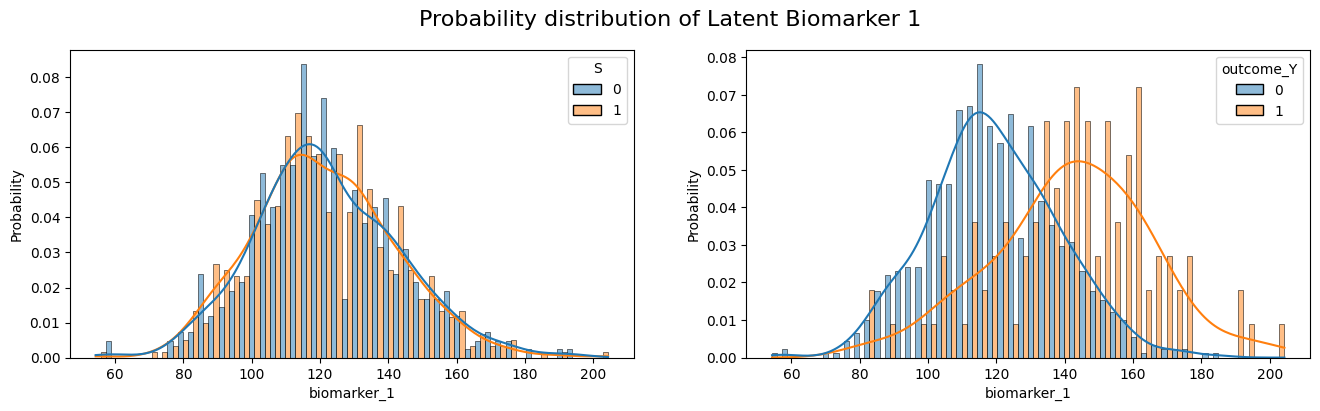

Biased feature


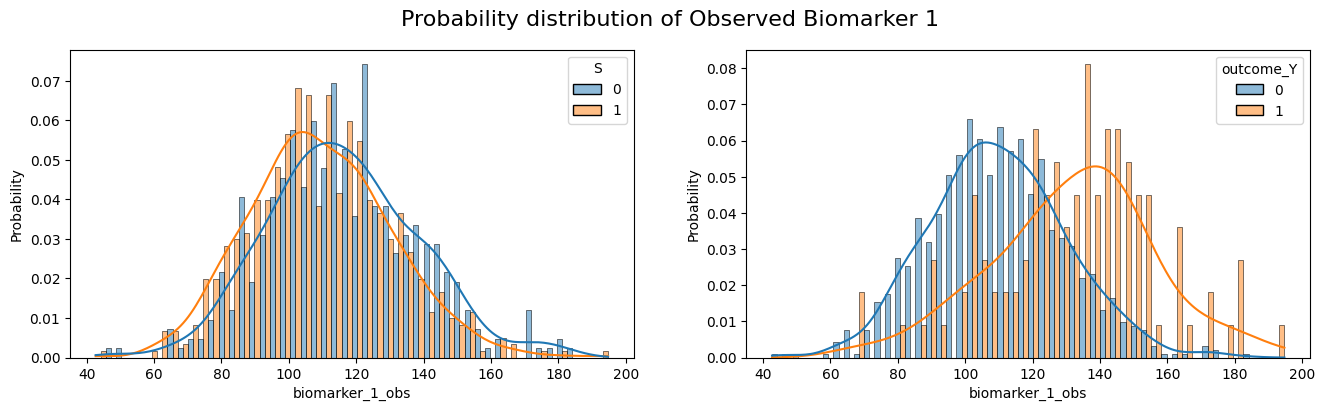

======= CLASS-BALANCED SAMPLING =======
Unbiased feature


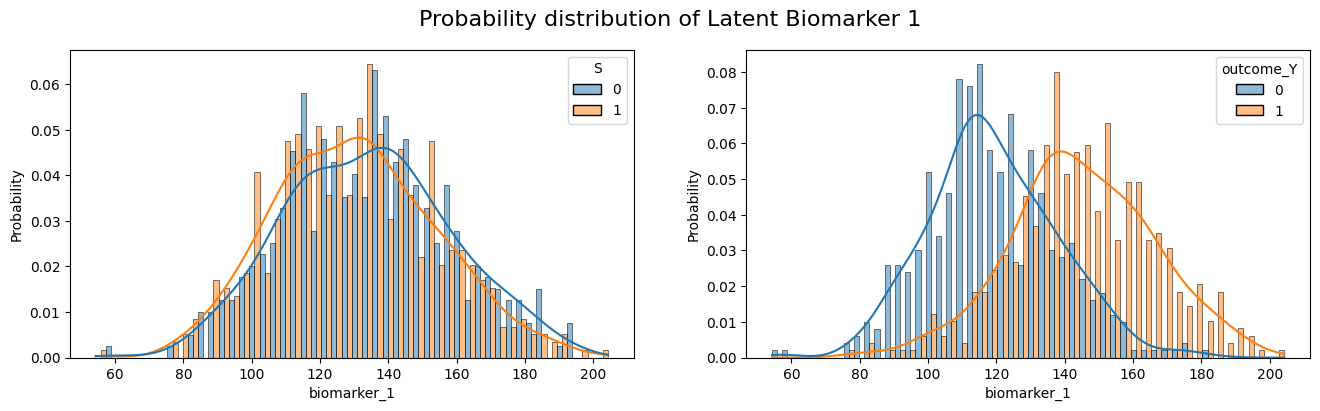

Biased feature


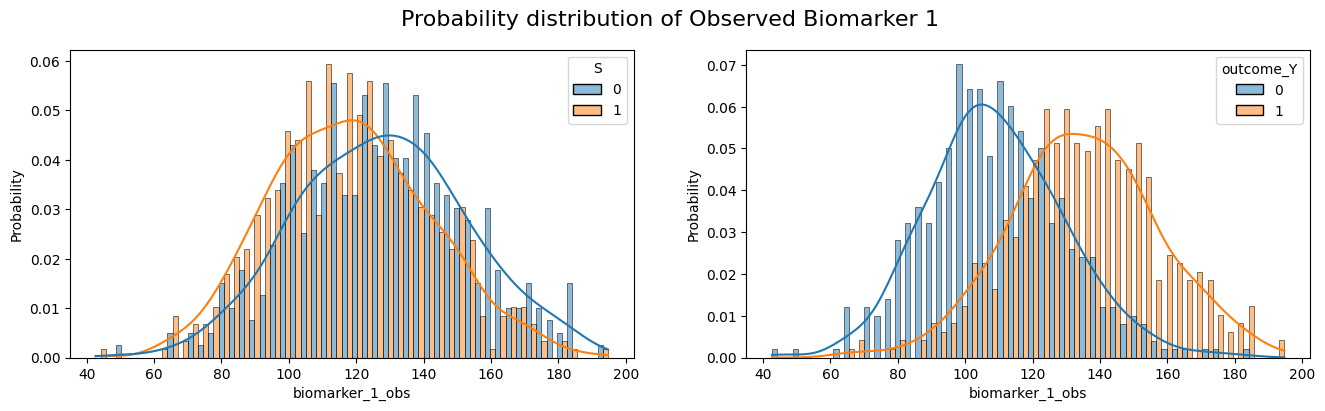

======= AGE SELECTION BIAS =======
Unbiased feature


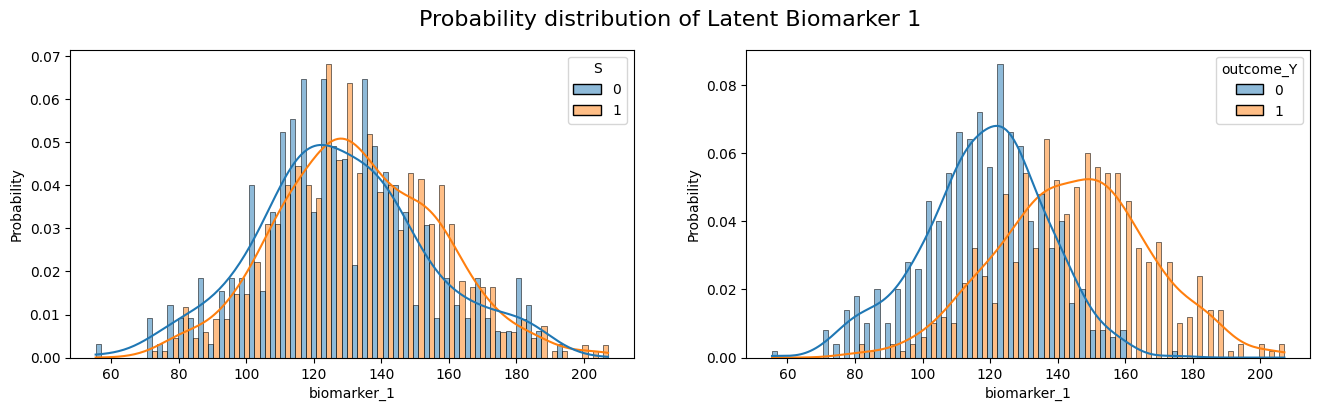

Biased feature


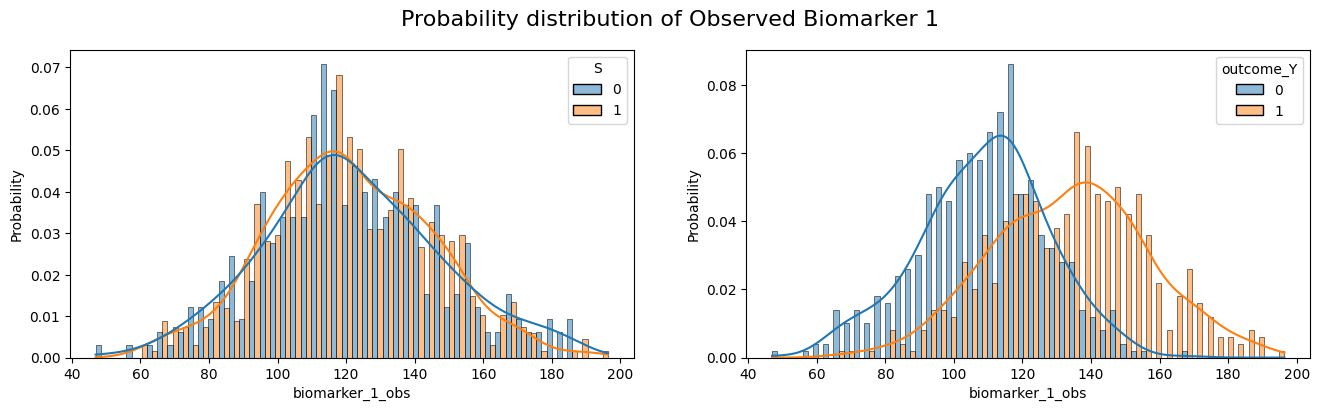

In [10]:
print(f'======= PROPORTION PRESERVING SAMPLING =======')
print(f'Unbiased feature')
fig = plot_cont_feature(add_test, "biomarker_1", "Latent Biomarker 1")
print(f'Biased feature')
fig = plot_cont_feature(add_test, "biomarker_1_obs", "Observed Biomarker 1")
print(f'======= CLASS-BALANCED SAMPLING =======')
print(f'Unbiased feature')
fig = plot_cont_feature(add_classbal_test, "biomarker_1", "Latent Biomarker 1")
print(f'Biased feature')
fig = plot_cont_feature(add_classbal_test, "biomarker_1_obs", "Observed Biomarker 1")
print(f'======= AGE SELECTION BIAS =======')
print(f'Unbiased feature')
fig = plot_cont_feature(add_selbias_test, "biomarker_1", "Latent Biomarker 1")
print(f'Biased feature')
fig = plot_cont_feature(add_selbias_test, "biomarker_1_obs", "Observed Biomarker 1")

======= PROPORTION PRESERVING SAMPLING =======
Unbiased feature


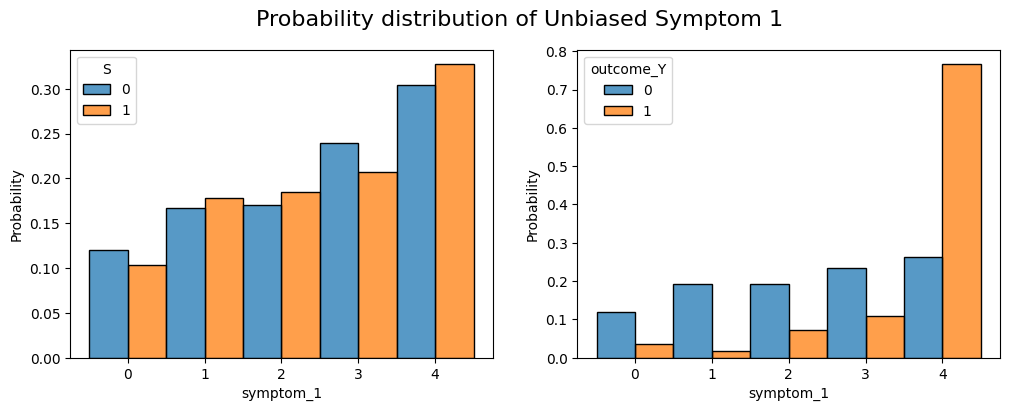

Biased feature


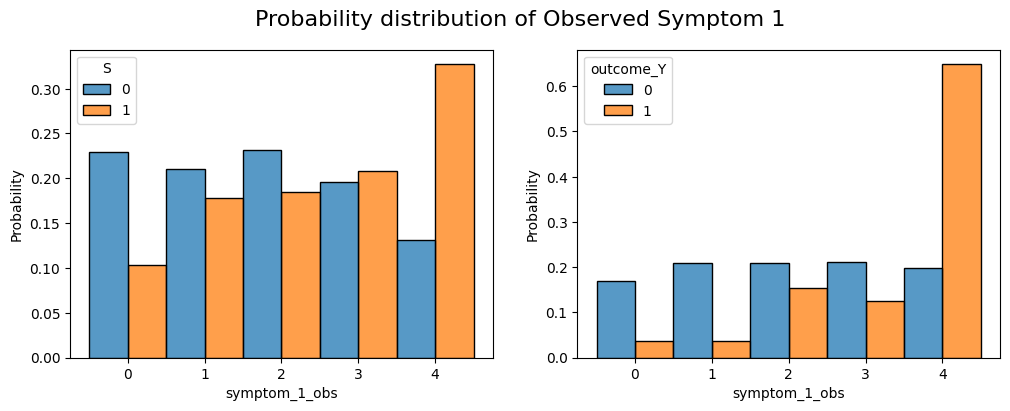

======= CLASS-BALANCED SAMPLING =======
Unbiased feature


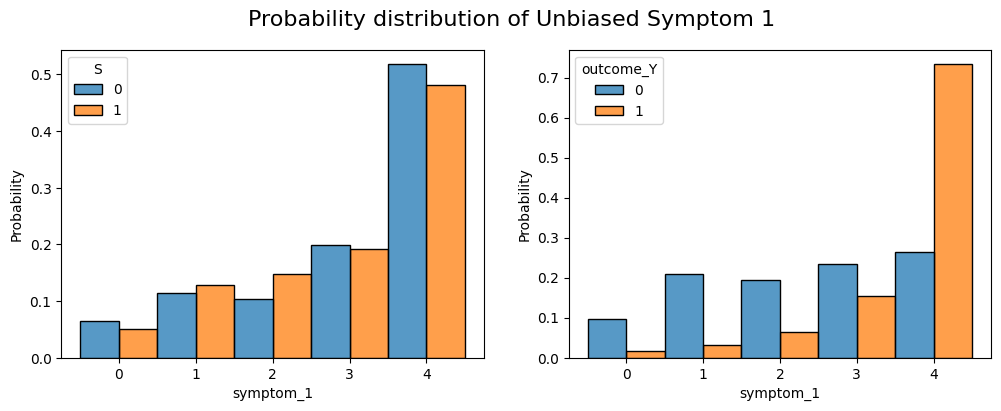

Biased feature


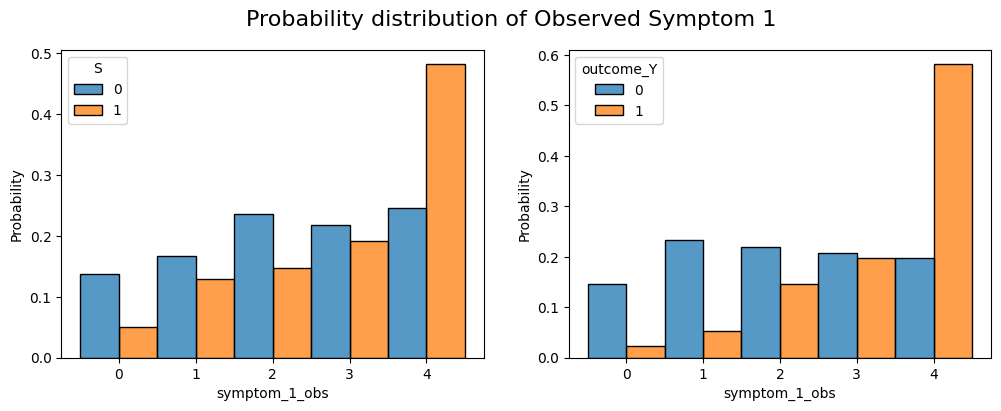

======= AGE SELECTION BIAS =======
Unbiased feature


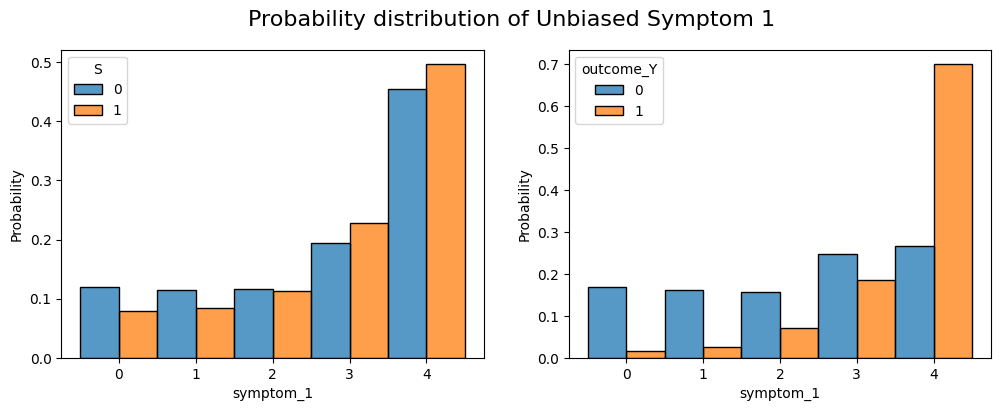

Biased feature


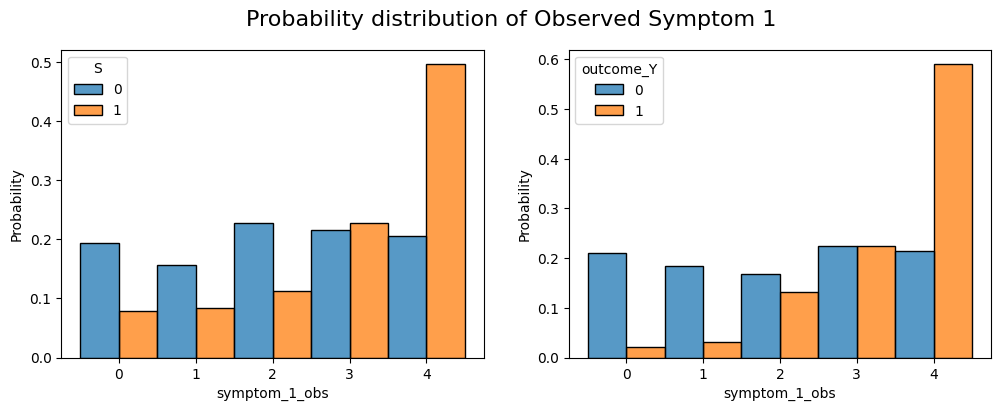

In [11]:
print(f'======= PROPORTION PRESERVING SAMPLING =======')
print(f'Unbiased feature')
fig = plot_cat_feature(add_test, "symptom_1", "Unbiased Symptom 1")
print(f'Biased feature')
fig = plot_cat_feature(add_test, "symptom_1_obs", "Observed Symptom 1")
print(f'======= CLASS-BALANCED SAMPLING =======')
print(f'Unbiased feature')
fig = plot_cat_feature(add_classbal_test, "symptom_1", "Unbiased Symptom 1")
print(f'Biased feature')
fig = plot_cat_feature(add_classbal_test, "symptom_1_obs", "Observed Symptom 1")
print(f'======= AGE SELECTION BIAS =======')
print(f'Unbiased feature')
fig = plot_cat_feature(add_selbias_test, "symptom_1", "Unbiased Symptom 1")
print(f'Biased feature')
fig = plot_cat_feature(add_selbias_test, "symptom_1_obs", "Observed Symptom 1")

======= PROPORTION PRESERVING SAMPLING =======


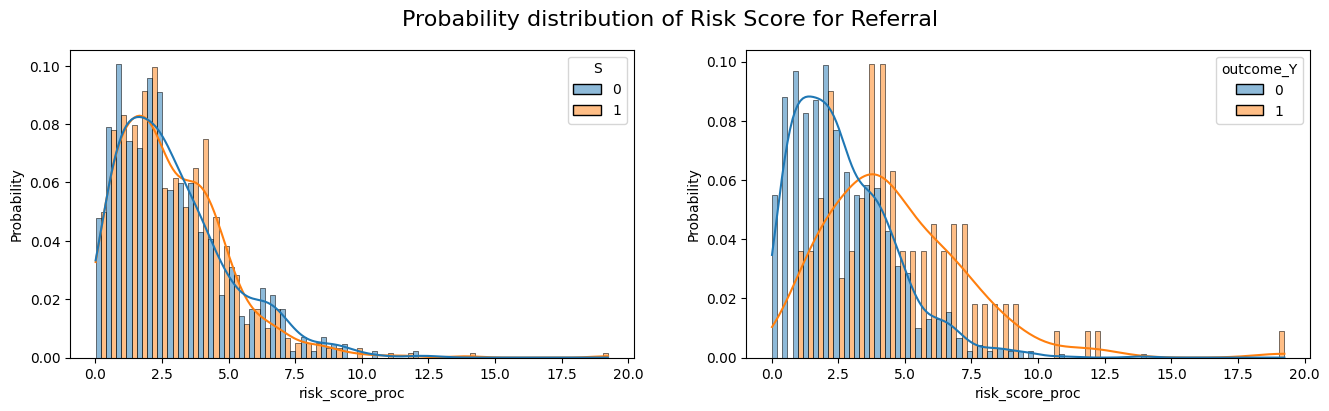

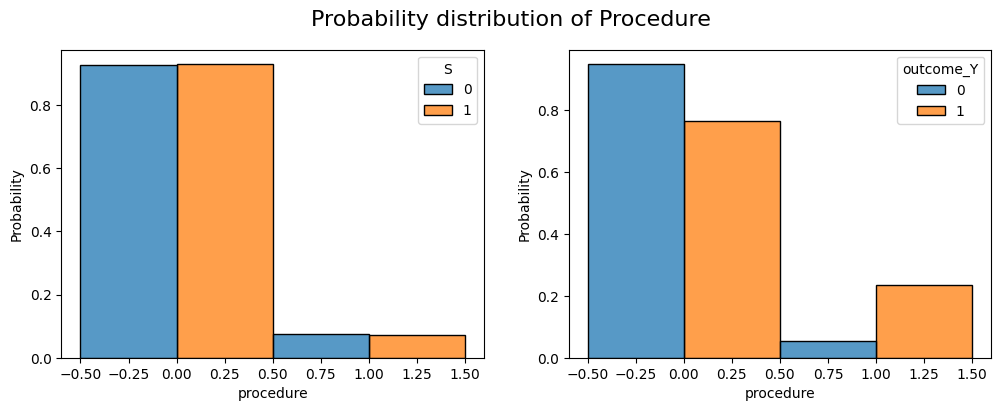

======= CLASS-BALANCED SAMPLING =======


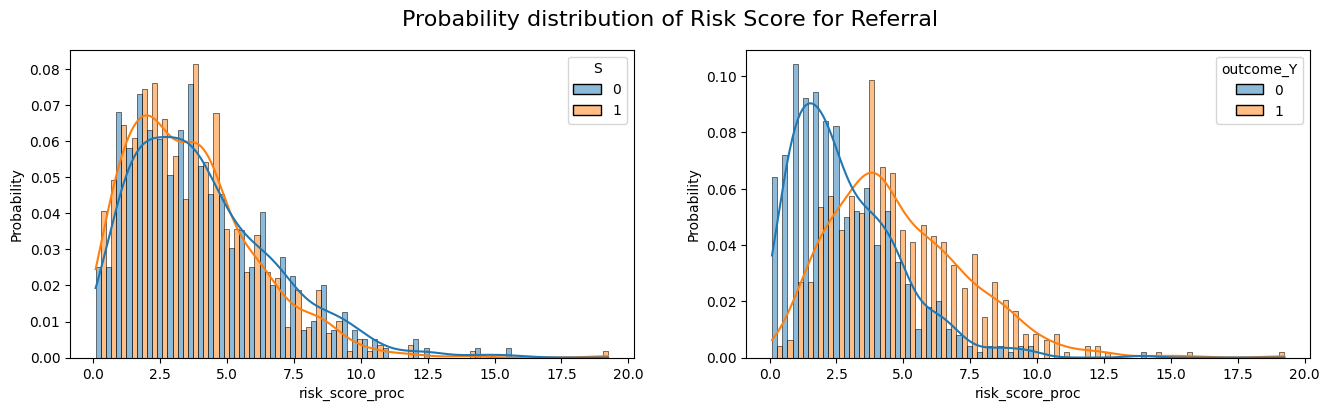

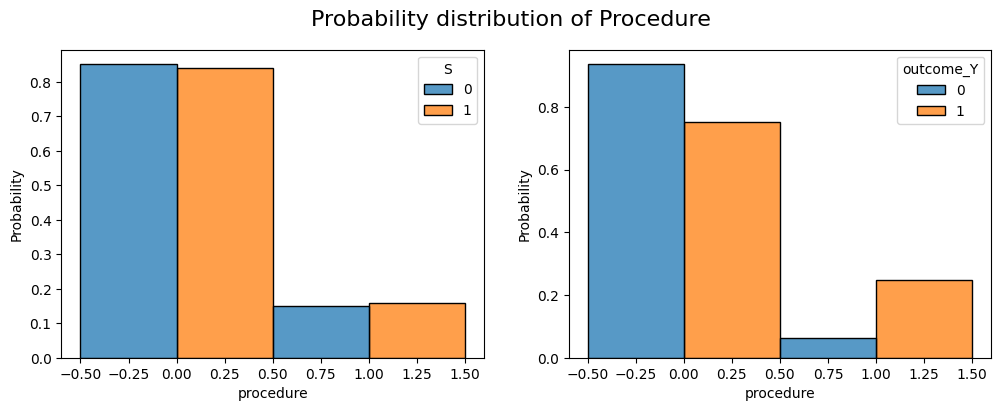

======= AGE SELECTION BIAS =======


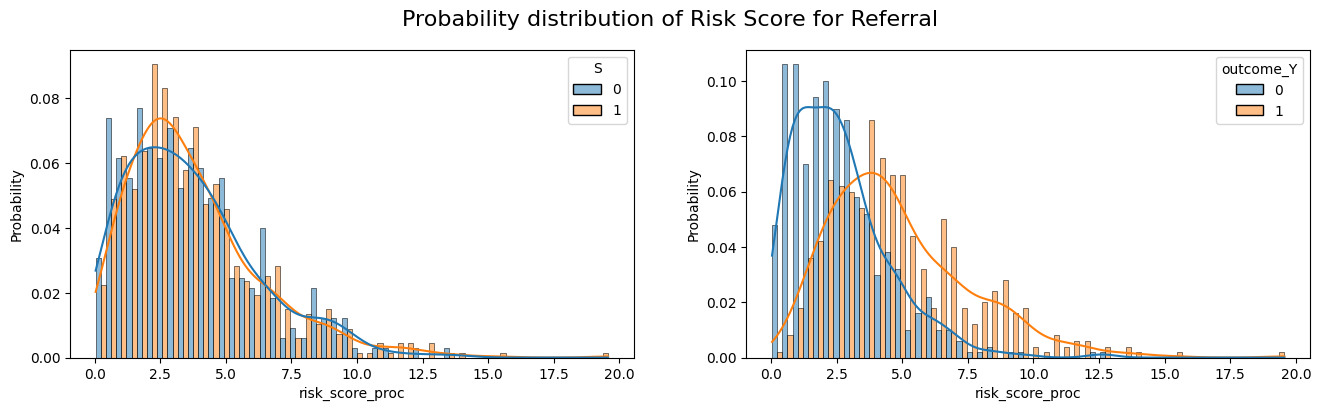

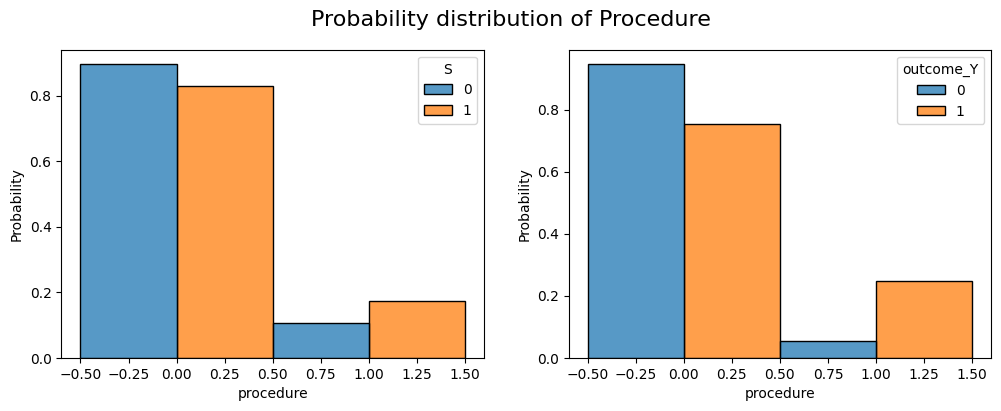

In [12]:
print(f'======= PROPORTION PRESERVING SAMPLING =======')
fig = plot_cont_feature(add_test, "risk_score_proc", "Risk Score for Referral")
fig = plot_cat_feature(add_test, "procedure", "Procedure")
print(f'======= CLASS-BALANCED SAMPLING =======')
fig = plot_cont_feature(add_classbal_test, "risk_score_proc", "Risk Score for Referral")
fig = plot_cat_feature(add_classbal_test, "procedure", "Procedure")
print(f'======= AGE SELECTION BIAS =======')
fig = plot_cont_feature(add_selbias_test, "risk_score_proc", "Risk Score for Referral")
fig = plot_cat_feature(add_selbias_test, "procedure", "Procedure")